In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec 
import matplotlib.ticker as mticker
from IPython.display import Image

In [29]:
# ============================================================
# [0] 폰트 설정
# ============================================================
plt.rcParams['font.family'] = 'NanumGothic'   # Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [30]:
# ============================================================
# [1] CSV 파일 불러오기
#     - 본인 파일 경로에 맞게 수정하세요
#     - 주민등록 인구통계 사이트에서 다운받은 파일 기준 (EUC-KR 인코딩)
# ============================================================
df_jeju_pop  = pd.read_csv('/home/dahyun/data_analisys_ex/datas/2016-2025_제주시_인구세대현황.csv',   encoding='euc-kr')
df_seo_pop   = pd.read_csv('datas/2016-2025_서귀포시_인구세대현황.csv', encoding='euc-kr')
# df_jeju_age = pd.read_csv('제주시_연령별인구.csv',    encoding='euc-kr')   # 연령 분석 시 사용
# df_seo_age  = pd.read_csv('서귀포시_연령별인구.csv',  encoding='euc-kr')   # 연령 분석 시 사용
 

In [31]:
# ============================================================
# [2] 데이터 전처리
#     - 시 전체 합계 행만 추출 (첫 번째 데이터 행)
#     - 연도별 총인구수 컬럼만 선택 → 깔끔한 DataFrame으로 변환
# ============================================================
 
# 연도 목록
years = list(range(2016, 2026))
 
# 총인구수 컬럼명 목록 (예: '2016년_총인구수', '2017년_총인구수' ...)
pop_cols = [f'{y}년_거주자 인구수' for y in years]
 
# 시 전체 합계 행 추출 (행정구역 코드가 시 단위인 첫 번째 행)
jeju_row = df_jeju_pop.iloc[0]
seo_row  = df_seo_pop.iloc[0]
 
# 연도별 인구수 추출 (쉼표 제거 후 숫자 변환)
def extract_pop(row, cols):
    return [int(str(row[c]).replace(',', '').strip()) for c in cols]
 
jeju_pop = extract_pop(jeju_row, pop_cols)
seo_pop  = extract_pop(seo_row,  pop_cols)
 
# 분석용 DataFrame 생성
df = pd.DataFrame({
    '연도':     years,
    '제주시':   jeju_pop,
    '서귀포시': seo_pop
})
 
# 파생 변수 계산
df['격차']      = df['제주시'] - df['서귀포시']
df['합계']      = df['제주시'] + df['서귀포시']
df['제주시비율']   = (df['제주시'] / df['합계'] * 100).round(1)
df['서귀포시비율'] = (df['서귀포시'] / df['합계'] * 100).round(1)
 
print(df.to_string(index=False))

  연도    제주시   서귀포시     격차     합계  제주시비율  서귀포시비율
2016 466780 169603 297177 636383   73.3    26.7
2017 474732 176998 297734 651730   72.8    27.2
2018 481832 179785 302047 661617   72.8    27.2
2019 485255 180105 305150 665360   72.9    27.1
2020 488423 180754 307669 669177   73.0    27.0
2021 490059 182749 307310 672808   72.8    27.2
2022 490735 183885 306850 674620   72.7    27.3
2023 488982 182596 306386 671578   72.8    27.2
2024 485574 180950 304624 666524   72.9    27.1
2025 482482 178627 303855 661109   73.0    27.0


In [32]:
# ============================================================
# [3] 공통 스타일 함수
# ============================================================
C_BLUE   = '#2a78d6'   # 제주시 색상
C_ORANGE = '#eb6834'   # 서귀포시 색상
C_GRID   = '#e0e0de'
C_TEXT   = '#1a1a19'
C_MUTED  = '#6b6b68'
 
def apply_style(ax, title, ylabel, ylim=None):
    """축·그리드·타이틀 등 공통 스타일 적용"""
    ax.set_title(title, fontsize=13, fontweight='bold',
                 color=C_TEXT, pad=12, loc='left')
    ax.set_ylabel(ylabel, fontsize=10, color=C_MUTED)
    ax.set_xlabel('연도', fontsize=10, color=C_MUTED)
    ax.set_xticks(df['연도'])
    ax.set_xticklabels(df['연도'].astype(str), fontsize=9, color=C_MUTED)
    ax.tick_params(axis='y', labelsize=9, labelcolor=C_MUTED)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color(C_GRID)
    ax.spines['bottom'].set_color(C_GRID)
    ax.grid(axis='y', color=C_GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    if ylim:
        ax.set_ylim(ylim)


findfont: Failed to find font weight bold, now using 600.


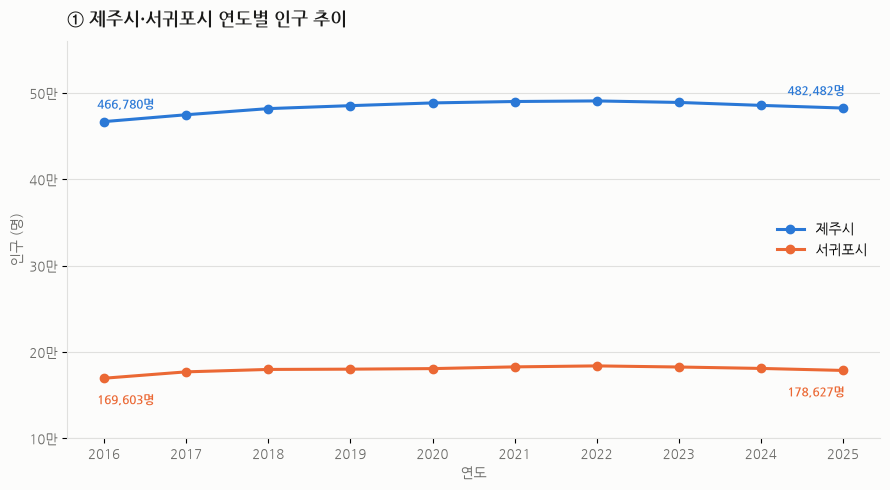

chart1_line.png 저장 완료


In [33]:
# ============================================================
# [4] 그래프 1 — 꺾은선: 두 도시 인구 추이
# ============================================================
fig1, ax1 = plt.subplots(figsize=(9, 5))
fig1.patch.set_facecolor('#fcfcfb')
ax1.set_facecolor('#fcfcfb')
 
ax1.plot(df['연도'], df['제주시'], color=C_BLUE, linewidth=2.2,
         marker='o', markersize=6, label='제주시')
ax1.plot(df['연도'], df['서귀포시'], color=C_ORANGE, linewidth=2.2,
         marker='o', markersize=6, label='서귀포시')
 
# 시작·끝 값 표기
ax1.annotate(f"{df['제주시'].iloc[0]:,}명",
             (df['연도'].iloc[0], df['제주시'].iloc[0]),
             xytext=(-5, 10), textcoords='offset points',
             fontsize=8.5, color=C_BLUE, fontweight='bold')
ax1.annotate(f"{df['제주시'].iloc[-1]:,}명",
             (df['연도'].iloc[-1], df['제주시'].iloc[-1]),
             xytext=(-40, 10), textcoords='offset points',
             fontsize=8.5, color=C_BLUE, fontweight='bold')
ax1.annotate(f"{df['서귀포시'].iloc[0]:,}명",
             (df['연도'].iloc[0], df['서귀포시'].iloc[0]),
             xytext=(-5, -18), textcoords='offset points',
             fontsize=8.5, color=C_ORANGE, fontweight='bold')
ax1.annotate(f"{df['서귀포시'].iloc[-1]:,}명",
             (df['연도'].iloc[-1], df['서귀포시'].iloc[-1]),
             xytext=(-40, -18), textcoords='offset points',
             fontsize=8.5, color=C_ORANGE, fontweight='bold')
 
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/10000)}만'))
ax1.legend(loc='center right', frameon=False, fontsize=10)
apply_style(ax1, '① 제주시·서귀포시 연도별 인구 추이', '인구 (명)',
            ylim=(100000, 560000))
 
plt.tight_layout()
plt.show()
fig1.savefig('chart1_line.png', dpi=150, bbox_inches='tight', facecolor='#fcfcfb')
plt.close()
print("chart1_line.png 저장 완료")

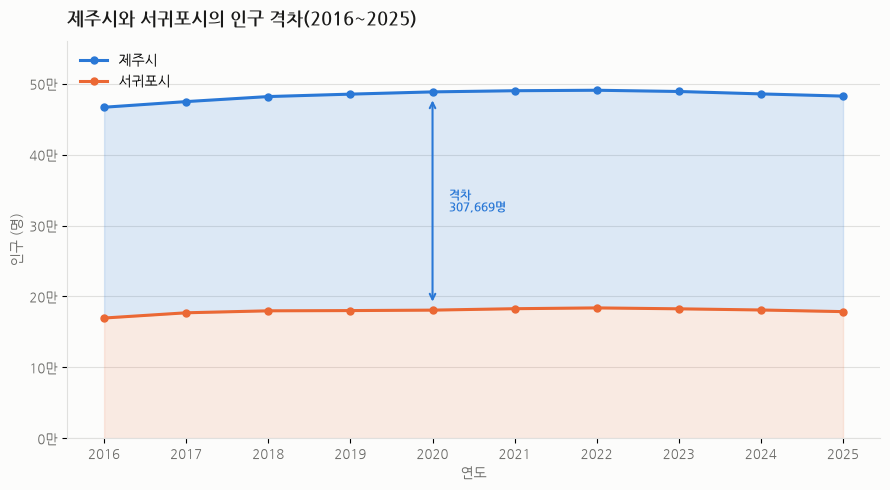

chart2_area.png 저장 완료


In [34]:
# ============================================================
# [5] 그래프 2 — 면적 강조: 두 도시 사이 격차를 음영으로 표현
# ============================================================
fig2, ax2 = plt.subplots(figsize=(9, 5))
fig2.patch.set_facecolor('#fcfcfb')
ax2.set_facecolor('#fcfcfb')
 
# 격차 음영
ax2.fill_between(df['연도'], df['제주시'], df['서귀포시'],
                 alpha=0.15, color=C_BLUE)
ax2.fill_between(df['연도'], df['서귀포시'], 0,
                 alpha=0.12, color=C_ORANGE)
 
ax2.plot(df['연도'], df['제주시'], color=C_BLUE, linewidth=2.2,
         marker='o', markersize=5, label='제주시')
ax2.plot(df['연도'], df['서귀포시'], color=C_ORANGE, linewidth=2.2,
         marker='o', markersize=5, label='서귀포시')
 
# 격차 화살표 (2020년 기준)
peak_year = df.loc[df['격차'].idxmax(), '연도']
peak_gap  = df['격차'].max()
mid_y     = (df.loc[df['연도'] == peak_year, '제주시'].values[0] +
             df.loc[df['연도'] == peak_year, '서귀포시'].values[0]) / 2
seo_peak  = df.loc[df['연도'] == peak_year, '서귀포시'].values[0]
jeju_peak = df.loc[df['연도'] == peak_year, '제주시'].values[0]
 
ax2.annotate('', xy=(peak_year, seo_peak + 8000),
             xytext=(peak_year, jeju_peak - 8000),
             arrowprops=dict(arrowstyle='<->', color=C_BLUE, lw=1.5))
ax2.text(peak_year + 0.2, mid_y, f'격차\n{peak_gap:,}명',
         fontsize=8.5, color=C_BLUE, fontweight='bold', va='center')
 
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/10000)}만'))
ax2.legend(loc='upper left', frameon=False, fontsize=10)
apply_style(ax2, '제주시와 서귀포시의 인구 격차(2016~2025)', '인구 (명)', ylim=(0, 560000))
 
plt.tight_layout()
plt.show()
fig2.savefig('chart2_area.png', dpi=150, bbox_inches='tight', facecolor='#fcfcfb')
plt.close()
print("chart2_area.png 저장 완료")

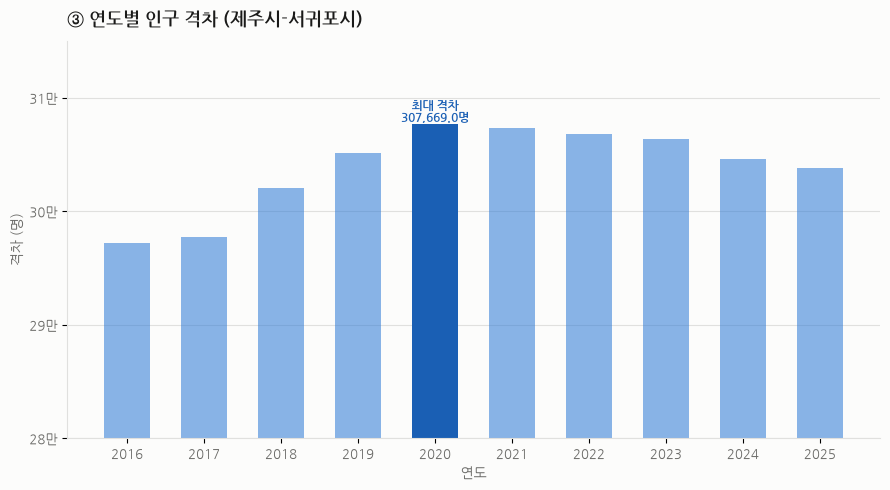

chart3_gap.png 저장 완료


In [35]:
# ============================================================
# [6] 그래프 3 — 막대: 격차(명)만 단독 표시
# ============================================================
fig3, ax3 = plt.subplots(figsize=(9, 5))
fig3.patch.set_facecolor('#fcfcfb')
ax3.set_facecolor('#fcfcfb')
 
# 최대 격차 연도 강조
bar_colors = [
    '#1a5fb4' if y == df.loc[df['격차'].idxmax(), '연도'] else C_BLUE
    for y in df['연도']
]
bar_alphas = [
    1.0 if y == df.loc[df['격차'].idxmax(), '연도'] else 0.55
    for y in df['연도']
]
 
bars = ax3.bar(df['연도'], df['격차'], width=0.6, color=bar_colors,
               edgecolor='white', linewidth=0)
for bar, alpha in zip(bars, bar_alphas):
    bar.set_alpha(alpha)
 
# 정점 수치 표기
peak_row = df.loc[df['격차'].idxmax()]
ax3.text(peak_row['연도'], peak_row['격차'] + 300,
         f"최대 격차\n{peak_row['격차']:,}명",
         ha='center', fontsize=8.5, color='#1a5fb4', fontweight='bold')
 
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/10000)}만'))
ax3.yaxis.set_major_locator(mticker.MultipleLocator(10000))
apply_style(ax3, '③ 연도별 인구 격차 (제주시-서귀포시)', '격차 (명)',
            ylim=(280000, 315000))
 
plt.tight_layout()
plt.show()
fig3.savefig('chart3_gap.png', dpi=150, bbox_inches='tight', facecolor='#fcfcfb')
plt.close()
print("chart3_gap.png 저장 완료")

findfont: Failed to find font weight bold, now using 600.


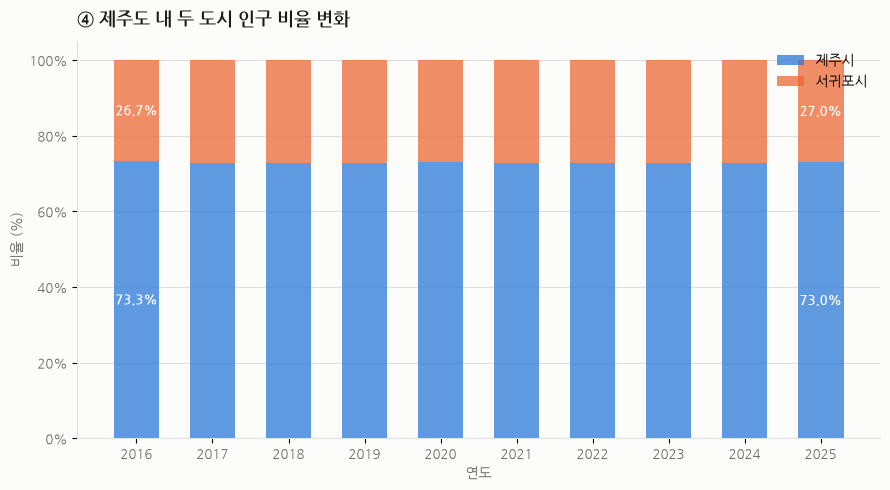

chart4_ratio.png 저장 완료

✅ 완료! 같은 폴더에 PNG 4개가 저장되었습니다.


In [36]:
# ============================================================
# [7] 그래프 4 — 누적 막대: 비율 변화 (10년간 고정됨을 강조)
# ============================================================
fig4, ax4 = plt.subplots(figsize=(9, 5))
fig4.patch.set_facecolor('#fcfcfb')
ax4.set_facecolor('#fcfcfb')
 
ax4.bar(df['연도'], df['제주시비율'], color=C_BLUE, alpha=0.75,
        width=0.6, label='제주시')
ax4.bar(df['연도'], df['서귀포시비율'], bottom=df['제주시비율'],
        color=C_ORANGE, alpha=0.75, width=0.6, label='서귀포시')
 
# 첫·끝 연도 비율 텍스트
for col, y_offset, c in [('제주시비율', 0.5, 'white'), ('서귀포시비율', 0.5, 'white')]:
    for _, row in df.iloc[[0, -1]].iterrows():
        if col == '제주시비율':
            y_pos = row[col] / 2
        else:
            y_pos = row['제주시비율'] + row[col] / 2
        ax4.text(row['연도'], y_pos,
                 f"{row[col]:.1f}%",
                 ha='center', va='center',
                 fontsize=9, color='white', fontweight='bold')
 
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)}%'))
ax4.legend(loc='upper right', frameon=False, fontsize=10)
apply_style(ax4, '④ 제주도 내 두 도시 인구 비율 변화', '비율 (%)', ylim=(0, 105))
 
plt.tight_layout()
plt.show()
fig4.savefig('chart4_ratio.png', dpi=150, bbox_inches='tight', facecolor='#fcfcfb')
plt.close()
print("chart4_ratio.png 저장 완료")
 
print("\n✅ 완료! 같은 폴더에 PNG 4개가 저장되었습니다.")

In [48]:
# ── CSV 로드 ──
# 파일명을 본인이 저장한 이름으로 바꾸세요
df_emd = pd.read_csv('/home/dahyun/data_analisys_ex/datas/2010-2025_서귀포시_읍면동_인구세대현황.csv', encoding='euc-kr')

# 인코딩 오류 나면 아래로 교체
# df_emd = pd.read_csv('20162025_서귀포시_읍면동_인구세대현황.csv', encoding='utf-8')

# ── 첫 컬럼명 강제 지정 ──
df_emd.columns.values[0] = '행정구역'

# ── 서귀포시 전체 합계 행 제외 ──
df_emd = df_emd[~df_emd['행정구역'].str.contains(r'서귀포시 \(', na=False)].copy()

# ── 지역명 추출 ──
df_emd['지역명'] = df_emd['행정구역'].apply(
    lambda x: x.strip().split(' ')[-1].split('(')[0]
)

# ── 연도 컬럼 이름 정리 ──
years = list(range(2016, 2026))
pop_cols = [f'{y}년_거주자 인구수' for y in years]

# 인구수 숫자 변환 (쉼표 제거)
for col in pop_cols:
    df_emd[col] = df_emd[col].apply(
        lambda v: int(str(v).replace(',', '').strip())
    )

# ── 증감 컬럼 추가 ──
df_emd['증감(명)']  = df_emd['2025년_거주자 인구수'] - df_emd['2016년_거주자 인구수']
df_emd['증감률(%)'] = ((df_emd['증감(명)'] / df_emd['2016년_거주자 인구수']) * 100).round(1)

# ── 필요한 컬럼만 남기고 정렬 ──
df_emd = df_emd[['지역명'] + pop_cols + ['증감(명)', '증감률(%)']].copy()
df_emd = df_emd.set_index('지역명')
df_emd = df_emd.sort_values('증감(명)', ascending=False)

df_emd

,2016년_거주자 인구수,2017년_거주자 인구수,2018년_거주자 인구수,2019년_거주자 인구수,2020년_거주자 인구수,2021년_거주자 인구수,2022년_거주자 인구수,2023년_거주자 인구수,2024년_거주자 인구수,2025년_거주자 인구수,증감(명),증감률(%)
지역명,,,,,,,,,,,,
대천동,8922,12931,13607,13718,13851,13773,13746,13596,13647,13661,4739,53.1
대정읍,19524,20874,21196,21154,21575,22073,22143,21939,21850,21478,1954,10.0
안덕면,10369,11316,11813,11961,11924,12174,12349,12430,12306,12231,1862,18.0
중문동,10144,10612,11078,11266,11522,11898,12264,12389,12194,12000,1856,18.3
대륜동,13177,13272,13844,14324,14651,15241,15510,15212,14981,14803,1626,12.3
표선면,11598,12135,12267,12176,12220,12321,12457,12522,12676,12698,1100,9.5
서홍동,10477,10579,10514,10383,10572,11037,11204,11144,11092,10995,518,4.9
영천동,4964,5146,5257,5247,5161,5187,5282,5247,5094,5042,78,1.6
효돈동,5155,5284,5237,5252,5220,5308,5294,5327,5325,5201,46,0.9


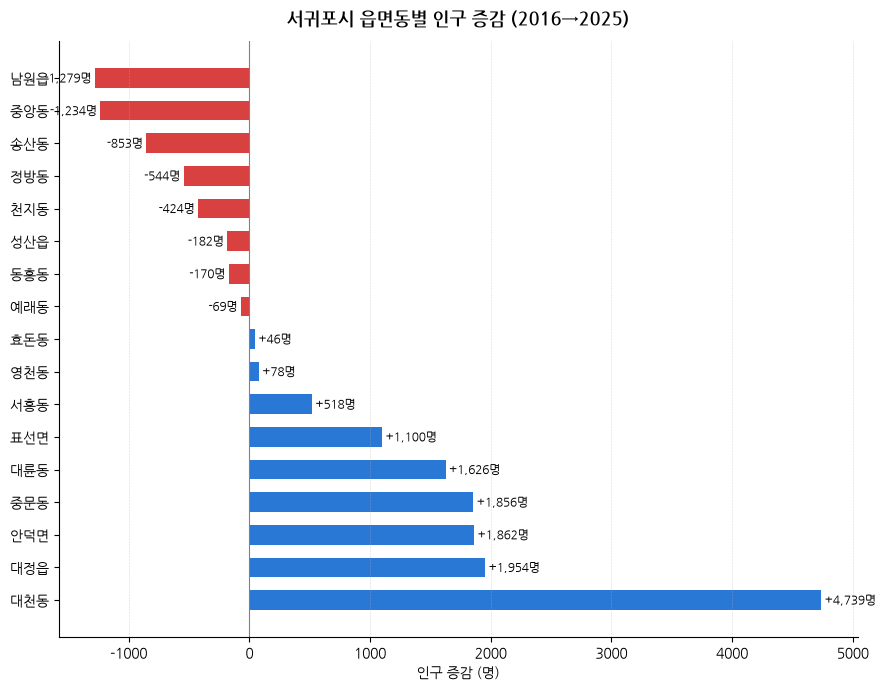

In [47]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

COLOR_UP   = '#2a78d6'
COLOR_DOWN = '#d94040'

colors = ['#2a78d6' if v >= 0 else '#d94040' for v in df_emd['증감(명)']]

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(df_emd.index, df_emd['증감(명)'], color=colors, height=0.6)

for bar, val in zip(bars, df_emd['증감(명)']):
    sign = '+' if val >= 0 else ''
    ax.text(
        val + (30 if val >= 0 else -30),
        bar.get_y() + bar.get_height() / 2,
        f'{sign}{val:,}명',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=8.5
    )

ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('인구 증감 (명)', fontsize=10)
ax.set_title('서귀포시 읍면동별 인구 증감 (2016→2025)',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

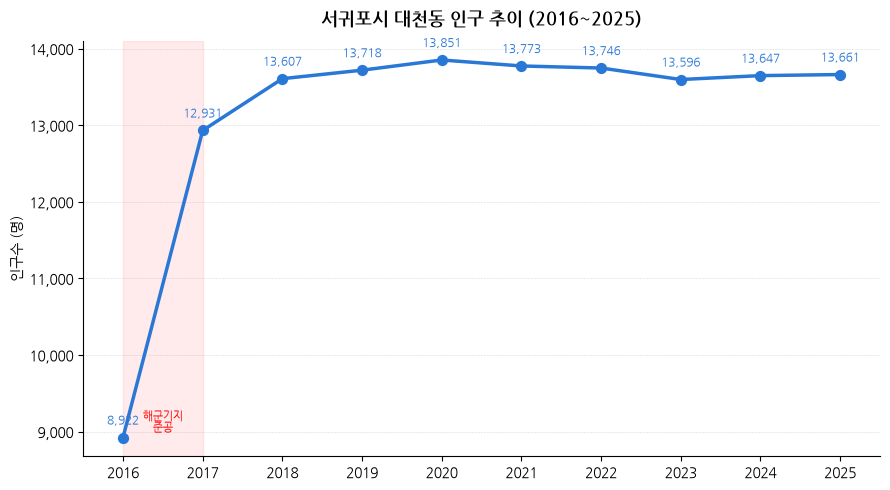

In [39]:
pop_cols = [f'{y}년_거주자 인구수' for y in range(2016, 2026)]
years = list(range(2016, 2026))

daecheon = df_emd.loc['대천동', pop_cols].values

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(years, daecheon, color='#2a78d6', linewidth=2.5, zorder=3)
ax.scatter(years, daecheon, color='#2a78d6', s=50, zorder=4)

for x, y in zip(years, daecheon):
    ax.annotate(f'{y:,}', xy=(x, y),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color='#2a78d6')

ax.axvspan(2016, 2017, alpha=0.08, color='red')
ax.text(2016.5, min(daecheon) * 1.01, '해군기지\n준공',
        ha='center', fontsize=8, color='red')

ax.set_xlim(2015.5, 2025.5)
ax.set_xticks(years)
ax.set_ylabel('인구수 (명)', fontsize=10)
ax.set_title('서귀포시 대천동 인구 추이 (2016~2025)', fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.show()

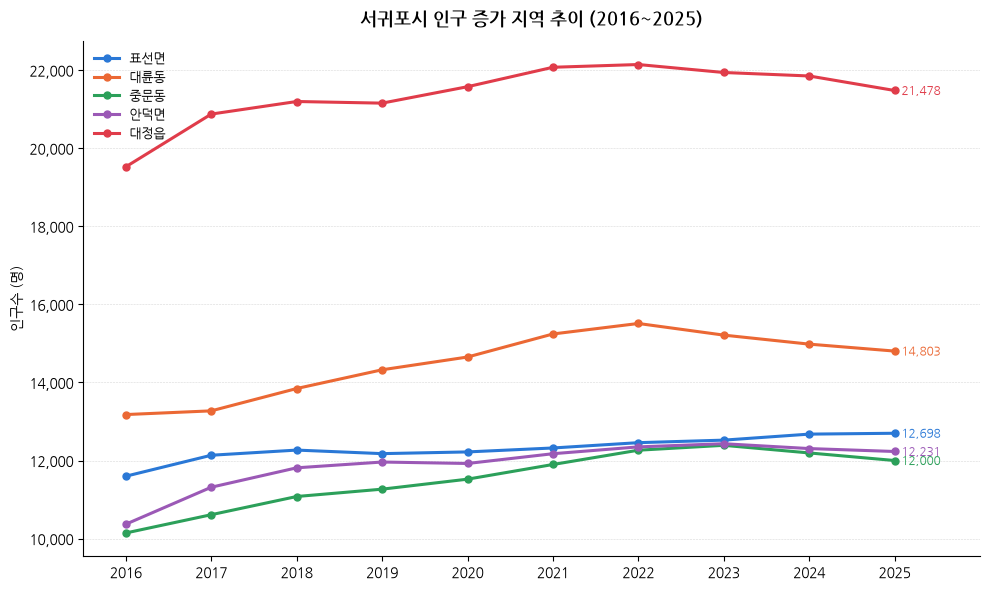

In [40]:
regions = ['표선면', '대륜동', '중문동', '안덕면', '대정읍']
pop_cols = [f'{y}년_거주자 인구수' for y in range(2016, 2026)]
years = list(range(2016, 2026))

colors = {
    '표선면': '#2a78d6',   # 파란색
    '대륜동': '#eb6834',   # 주황색
    '중문동': '#2ca05a',   # 초록색
    '안덕면': '#9b59b6',   # 보라색
    '대정읍': '#e03c4a'    # 빨간색
}

fig, ax = plt.subplots(figsize=(10, 6))

for region in regions:
    values = df_emd.loc[region, pop_cols].values
    ax.plot(years, values, color=colors[region],
            linewidth=2.2, marker='o', markersize=5, label=region)
    # 2025년 끝값 표시
    ax.annotate(f'{values[-1]:,}',
                xy=(2025, values[-1]),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=8.5, color=colors[region])

ax.set_xlim(2015.5, 2026)
ax.set_xticks(years)
ax.set_ylabel('인구수 (명)', fontsize=10)
ax.set_title('서귀포시 인구 증가 지역 추이 (2016~2025)', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.show()

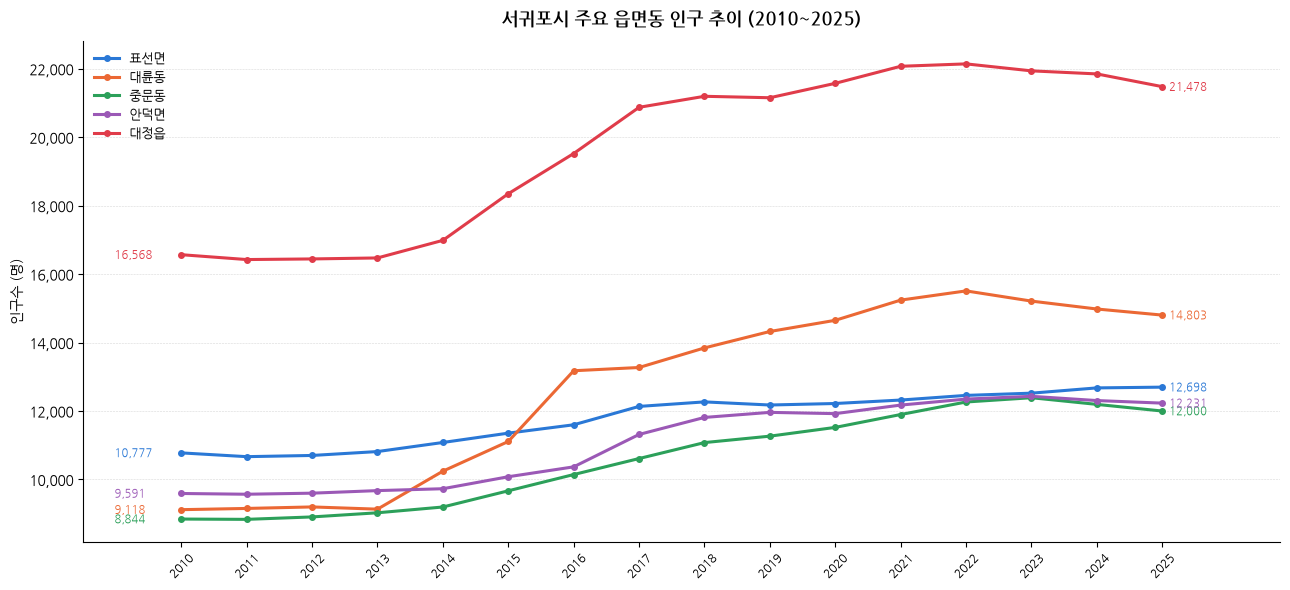

In [41]:
# ── CSV 로드 ──
df = pd.read_csv('/home/dahyun/data_analisys_ex/datas/2010-2025_서귀포시_읍면동_인구세대현황.csv', encoding='euc-kr')
df.columns.values[0] = '행정구역'   # BOM 문자 제거

# ── 읍면동만 필터링 ──
df_emd = df[
    df['행정구역'].str.contains('서귀포시', na=False) &
    ~df['행정구역'].str.contains(r'서귀포시 \(', na=False)
].copy()
df_emd['지역명'] = df_emd['행정구역'].apply(
    lambda x: x.strip().split(' ')[-1].split('(')[0]
)

# ── 연도 설정 (2010~2025) ──
years    = list(range(2010, 2026))
pop_cols = [f'{y}년_거주자 인구수' for y in years]

df_emd = df_emd.set_index('지역명')
for col in pop_cols:
    df_emd[col] = df_emd[col].apply(lambda v: int(str(v).replace(',', '').strip()))

# ── 5개 지역 색상 ──
regions = ['표선면', '대륜동', '중문동', '안덕면', '대정읍']
colors  = {
    '표선면': '#2a78d6',
    '대륜동': '#eb6834',
    '중문동': '#2ca05a',
    '안덕면': '#9b59b6',
    '대정읍': '#e03c4a',
}

# ── 그래프 ──
fig, ax = plt.subplots(figsize=(13, 6))

for region in regions:
    values = df_emd.loc[region, pop_cols].values
    ax.plot(years, values,
            color=colors[region], linewidth=2.2, marker='o', markersize=4, label=region)
    # 2010 시작값
    ax.annotate(f'{values[0]:,}', xy=(2010, values[0]),
                xytext=(-48, 0), textcoords='offset points',
                va='center', fontsize=8, color=colors[region])
    # 2025 끝값
    ax.annotate(f'{values[-1]:,}', xy=(2025, values[-1]),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=8, color=colors[region])

ax.set_xlim(2008.5, 2026.8)
ax.set_xticks(years)
ax.tick_params(axis='x', labelsize=8.5, rotation=45)
ax.set_ylabel('인구수 (명)', fontsize=10)
ax.set_title('서귀포시 주요 읍면동 인구 추이 (2010~2025)', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.show()

findfont: Failed to find font weight bold, now using 600.


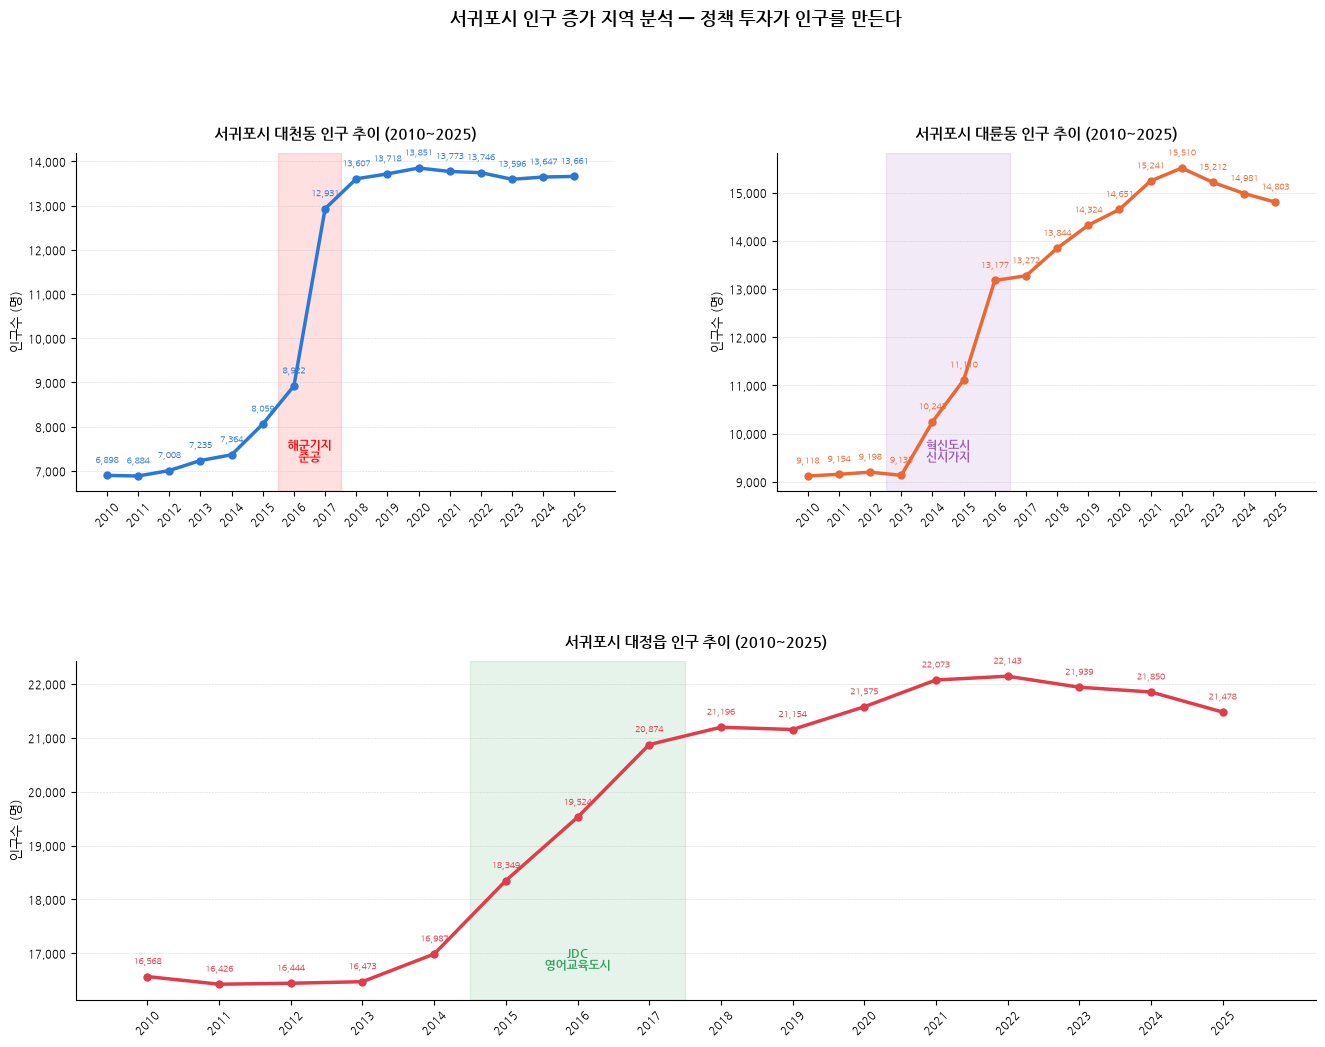

저장 완료: seogwipo_3regions.png


In [42]:
# ── CSV 로드 ──
df = pd.read_csv('/home/dahyun/data_analisys_ex/datas/2010-2025_서귀포시_읍면동_인구세대현황.csv', encoding='euc-kr')
df.columns.values[0] = '행정구역'

df_emd = df[
    df['행정구역'].str.contains('서귀포시', na=False) &
    ~df['행정구역'].str.contains(r'서귀포시 \(', na=False)
].copy()
df_emd['지역명'] = df_emd['행정구역'].apply(
    lambda x: x.strip().split(' ')[-1].split('(')[0]
)

years    = list(range(2010, 2026))
pop_cols = [f'{y}년_거주자 인구수' for y in years]

df_emd = df_emd.set_index('지역명')
for col in pop_cols:
    df_emd[col] = df_emd[col].apply(lambda v: int(str(v).replace(',', '').strip()))


# ── 공통 그래프 함수 ──
def draw_region(ax, region, line_color, hl_start, hl_end,
                hl_color, hl_label, hl_label_x):
    values = df_emd.loc[region, pop_cols].values

    # 라인 + 점
    ax.plot(years, values, color=line_color, linewidth=2.5,
            marker='o', markersize=5, zorder=3)

    # 데이터 레이블 (모든 연도)
    for x, y in zip(years, values):
        ax.annotate(f'{y:,}', xy=(x, y),
                    xytext=(0, 9), textcoords='offset points',
                    ha='center', fontsize=6.8, color=line_color)

    # 하이라이트 음영
    ax.axvspan(hl_start, hl_end, alpha=0.12, color=hl_color, zorder=1)

    # 하이라이트 텍스트 (음영 아래쪽에 배치)
    y_min = min(values)
    y_max = max(values)
    label_y = y_min + (y_max - y_min) * 0.05
    ax.text(hl_label_x, label_y, hl_label,
            ha='center', fontsize=8.5, color=hl_color, fontweight='bold')

    # 축 스타일
    ax.set_xlim(2009, 2026.3)
    ax.set_xticks(years)
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title(f'서귀포시 {region} 인구 추이 (2010~2025)',
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel('인구수 (명)', fontsize=9)
    ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))


# ── 레이아웃: 2×2 그리드, 대정읍은 하단 전체 차지 ──
# plt.subplot(2,2,1) 스타일과 같은 구조를 GridSpec으로 구현
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])   # (2,2,1) 위치 — 대천동
ax2 = fig.add_subplot(gs[0, 1])   # (2,2,2) 위치 — 대륜동
ax3 = fig.add_subplot(gs[1, :])   # (2,2,3+4) 하단 전체 — 대정읍


# ── 대천동: 강정해군기지 준공 (2016→2017 급등) ──
draw_region(ax1, '대천동',
            line_color='#2a78d6',
            hl_start=2015.5, hl_end=2017.5,
            hl_color='red', hl_label='해군기지\n준공',
            hl_label_x=2016.5)

# ── 대륜동: 서귀포혁신도시 신시가지 조성 (2013~2016 증가) ──
draw_region(ax2, '대륜동',
            line_color='#eb6834',
            hl_start=2012.5, hl_end=2016.5,
            hl_color='#9b59b6', hl_label='혁신도시\n신시가지',
            hl_label_x=2014.5)

# ── 대정읍: JDC 제주영어교육도시 (2014~2017 급증) ──
draw_region(ax3, '대정읍',
            line_color='#e03c4a',
            hl_start=2014.5, hl_end=2017.5,
            hl_color='#2ca05a', hl_label='JDC\n영어교육도시',
            hl_label_x=2016)


fig.suptitle('서귀포시 인구 증가 지역 분석 — 정책 투자가 인구를 만든다',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig('seogwipo_3regions.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: seogwipo_3regions.png")

findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight bold, now using 600.


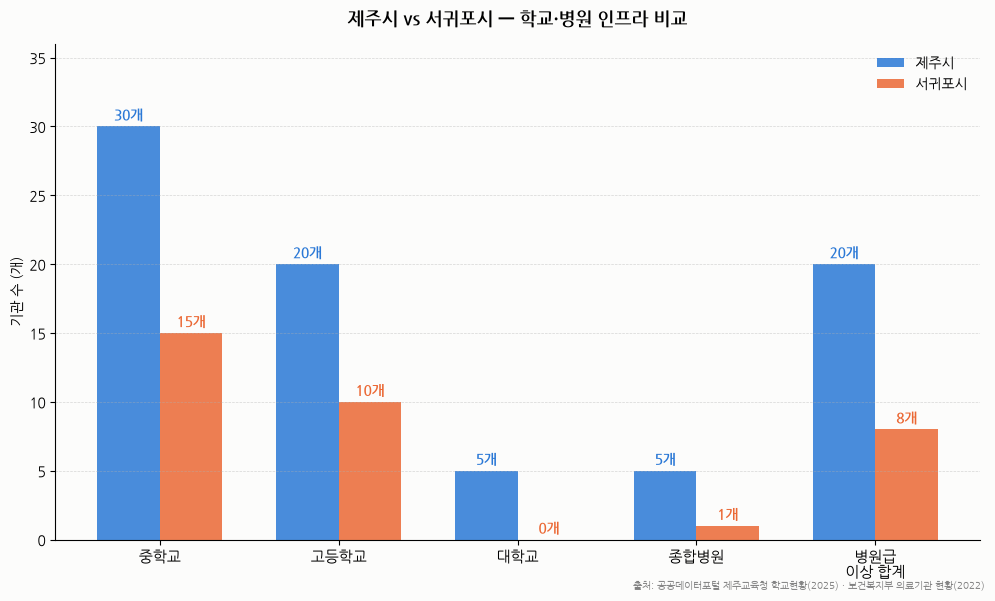

저장 완료: jeju_infra_compare.png


In [43]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os

# ── 한글 폰트 ──
for fp in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
           '/usr/share/fonts/nanum/NanumGothic.ttf']:
    if os.path.exists(fp):
        fm.fontManager.addfont(fp)
        plt.rcParams['font.family'] = fm.FontProperties(fname=fp).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 ──
categories = ['중학교', '고등학교', '대학교', '종합병원', '병원급\n이상 합계']
jeju    = [30, 20, 5, 5, 20]
seogwipo = [15, 10, 0, 1,  8]

C_JEJU     = '#2a78d6'   # 제주시 파랑
C_SEOGWIPO = '#eb6834'   # 서귀포시 주황

x     = np.arange(len(categories))
width = 0.35

# ── 그래프 ──
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#fcfcfb')
ax.set_facecolor('#fcfcfb')

bars_j = ax.bar(x - width/2, jeju,    width, label='제주시',    color=C_JEJU,     alpha=0.85)
bars_s = ax.bar(x + width/2, seogwipo, width, label='서귀포시', color=C_SEOGWIPO, alpha=0.85)

# 막대 위 숫자 표시
for bar in bars_j:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f'{int(h)}개', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=C_JEJU)

for bar in bars_s:
    h = bar.get_height()
    label = f'{int(h)}개' if h > 0 else '0개'
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            label, ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=C_SEOGWIPO)

# ── 축 스타일 ──
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('기관 수 (개)', fontsize=10)
ax.set_title('제주시 vs 서귀포시 — 학교·병원 인프라 비교',
             fontsize=13, fontweight='bold', pad=14)
ax.legend(fontsize=10, frameon=False)
ax.set_ylim(0, max(jeju) * 1.2)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

# 출처 주석
fig.text(0.99, 0.01,
         '출처: 공공데이터포털 제주교육청 학교현황(2025) · 보건복지부 의료기관 현황(2022)',
         ha='right', fontsize=7.5, color='gray')

plt.tight_layout()
plt.savefig('jeju_infra_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: jeju_infra_compare.png")

In [44]:
import folium
import pandas as pd
import os

# ──────────────────────────────────────────────
# [1] 폰트 설정 (터미널 출력용)
# ──────────────────────────────────────────────
# folium은 HTML이므로 별도 폰트 설정 불필요

# ──────────────────────────────────────────────
# [2] 서귀포시 CSV 로드 → 2025년 인구수 추출
# ──────────────────────────────────────────────
df = pd.read_csv('/home/dahyun/data_analisys_ex/datas/2010-2025_서귀포시_읍면동_인구세대현황.csv', encoding='euc-kr')
df.columns.values[0] = '행정구역'

df_emd = df[
    df['행정구역'].str.contains('서귀포시', na=False) &
    ~df['행정구역'].str.contains(r'서귀포시 \(', na=False)
].copy()

df_emd['지역명'] = df_emd['행정구역'].apply(
    lambda x: x.strip().split(' ')[-1].split('(')[0]
)
df_emd['인구수_2025'] = df_emd['2025년_거주자 인구수'].apply(
    lambda v: int(str(v).replace(',', '').strip())
)

seo_pop = dict(zip(df_emd['지역명'], df_emd['인구수_2025']))

# ──────────────────────────────────────────────
# [3] 좌표 딕셔너리 (서귀포시 17개 읍면동)
# ──────────────────────────────────────────────
seo_coords = {
    '대정읍': (33.2375, 126.2538),
    '남원읍': (33.2815, 126.6839),
    '성산읍': (33.4387, 126.9205),
    '안덕면': (33.2584, 126.3635),
    '표선면': (33.3243, 126.8385),
    '송산동': (33.2507, 126.5620),
    '정방동': (33.2470, 126.5669),
    '중앙동': (33.2491, 126.5581),
    '천지동': (33.2525, 126.5563),
    '효돈동': (33.2956, 126.6105),
    '영천동': (33.2718, 126.5805),
    '동홍동': (33.2617, 126.5674),
    '서홍동': (33.2746, 126.5335),
    '대륜동': (33.2916, 126.4942),
    '대천동': (33.2946, 126.5072),
    '중문동': (33.2494, 126.4802),
    '예래동': (33.2441, 126.4488),
}

# ──────────────────────────────────────────────
# [4] 제주시 읍면동 좌표 + 2025 인구수
#     ※ 행정안전부 주민등록 인구통계 2025년 기준
#        (출처: 행정안전부 주민등록 인구통계 https://jumin.mois.go.kr)
# ──────────────────────────────────────────────
# 제주시 CSV가 있다면 아래 dict 대신 read_csv로 교체 가능
jeju_emd = {
    '한림읍':  {'coords': (33.4140, 126.2682), 'pop': 24012},
    '애월읍':  {'coords': (33.4631, 126.3143), 'pop': 34876},
    '구좌읍':  {'coords': (33.5282, 126.7882), 'pop': 17521},
    '조천읍':  {'coords': (33.5386, 126.6437), 'pop': 22304},
    '한경면':  {'coords': (33.3498, 126.1916), 'pop': 14289},
    '추자면':  {'coords': (33.9612, 126.3002), 'pop': 1698},
    '우도면':  {'coords': (33.5041, 126.9519), 'pop': 1815},
    '일도1동': {'coords': (33.5127, 126.5228), 'pop': 6983},
    '일도2동': {'coords': (33.5189, 126.5315), 'pop': 21547},
    '이도1동': {'coords': (33.5043, 126.5278), 'pop': 12764},
    '이도2동': {'coords': (33.4956, 126.5412), 'pop': 34218},
    '삼도1동': {'coords': (33.5088, 126.5157), 'pop': 6241},
    '삼도2동': {'coords': (33.5013, 126.5193), 'pop': 14832},
    '용담1동': {'coords': (33.5155, 126.5027), 'pop': 10318},
    '용담2동': {'coords': (33.5096, 126.4872), 'pop': 12754},
    '건입동':  {'coords': (33.5218, 126.5430), 'pop': 8247},
    '화북동':  {'coords': (33.5137, 126.5688), 'pop': 28413},
    '삼양동':  {'coords': (33.5262, 126.5923), 'pop': 17986},
    '봉개동':  {'coords': (33.4758, 126.5823), 'pop': 8754},
    '아라동':  {'coords': (33.4701, 126.5415), 'pop': 35612},
    '오라동':  {'coords': (33.4832, 126.5108), 'pop': 14978},
    '연동':    {'coords': (33.4896, 126.4937), 'pop': 29741},
    '노형동':  {'coords': (33.4796, 126.4677), 'pop': 51238},
    '외도동':  {'coords': (33.4872, 126.4427), 'pop': 17245},
    '이호동':  {'coords': (33.5003, 126.4587), 'pop': 10623},
    '도두동':  {'coords': (33.5094, 126.4719), 'pop': 5254},
}

# ──────────────────────────────────────────────
# [5] folium 지도 생성
# ──────────────────────────────────────────────
m = folium.Map(
    location=[33.38, 126.56],
    zoom_start=10,
    tiles='CartoDB positron'
)

# ── 레이어 그룹 (범례 역할) ──
layer_seo  = folium.FeatureGroup(name='서귀포시 읍면동', show=True)
layer_jeju = folium.FeatureGroup(name='제주시 읍면동',   show=True)

C_JEJU     = '#2a78d6'   # 제주시 파란색
C_SEOGWIPO = '#eb6834'   # 서귀포시 주황색

def pop_to_radius(pop, base=5000, min_r=6, max_r=22):
    """인구수 → 원 반지름 (로그 스케일 느낌)"""
    import math
    r = min_r + (max_r - min_r) * math.log(pop / base + 1) / math.log(12)
    return max(min_r, min(max_r, r))

# ── 서귀포시 마커 ──
for name, (lat, lon) in seo_coords.items():
    pop = seo_pop.get(name, 0)
    radius = pop_to_radius(pop)

    popup_html = f"""
    <div style="font-family: 'Malgun Gothic', sans-serif; min-width:140px;">
      <b style="color:{C_SEOGWIPO}; font-size:14px;">서귀포시 {name}</b><br>
      <hr style="margin:4px 0;">
      <span style="font-size:13px;">2025년 인구</span><br>
      <span style="font-size:18px; font-weight:bold; color:{C_SEOGWIPO};">{pop:,}명</span>
    </div>"""

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=C_SEOGWIPO,
        weight=2,
        fill=True,
        fill_color=C_SEOGWIPO,
        fill_opacity=0.55,
        tooltip=folium.Tooltip(f"서귀포시 {name}  {pop:,}명", sticky=False),
        popup=folium.Popup(popup_html, max_width=200)
    ).add_to(layer_seo)

# ── 제주시 마커 ──
for name, info in jeju_emd.items():
    lat, lon = info['coords']
    pop = info['pop']
    radius = pop_to_radius(pop, base=5000)

    popup_html = f"""
    <div style="font-family: 'Malgun Gothic', sans-serif; min-width:140px;">
      <b style="color:{C_JEJU}; font-size:14px;">제주시 {name}</b><br>
      <hr style="margin:4px 0;">
      <span style="font-size:13px;">2025년 인구</span><br>
      <span style="font-size:18px; font-weight:bold; color:{C_JEJU};">{pop:,}명</span>
    </div>"""

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=C_JEJU,
        weight=2,
        fill=True,
        fill_color=C_JEJU,
        fill_opacity=0.55,
        tooltip=folium.Tooltip(f"제주시 {name}  {pop:,}명", sticky=False),
        popup=folium.Popup(popup_html, max_width=200)
    ).add_to(layer_jeju)

layer_seo.add_to(m)
layer_jeju.add_to(m)

# ── 레이어 컨트롤 (체크박스로 도시별 on/off) ──
folium.LayerControl(collapsed=False).add_to(m)

# ── 제목 박스 ──
title_html = """
<div style="position:fixed; top:12px; left:50%; transform:translateX(-50%);
     background:white; padding:10px 18px; border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.2); z-index:1000;
     font-family:'Malgun Gothic',sans-serif; text-align:center;">
  <b style="font-size:15px;">제주도 읍면동별 2025년 인구 현황</b><br>
  <span style="font-size:11px; color:#888;">원 크기 = 인구수 비례 · 클릭하면 상세 팝업</span>
</div>"""
m.get_root().html.add_child(folium.Element(title_html))

# ── 저장 ──
m.save('jeju_population_map.html')
print("저장 완료: jeju_population_map.html")
print(os.path.abspath('jeju_population_map.html'))

저장 완료: jeju_population_map.html
/home/dahyun/data_analisys_ex/jeju_population_map.html
